# Week 6 Exercises — Report

**Course:** Data-Driven Methods  
**Author:** Dimitris Papantzikos  
**Date:** March 12, 2026

---

## Abstract
This report investigates Dynamic Mode Decomposition (DMD) and its variants across two settings. **Exercise 1** examines the sensitivity of standard DMD, Forward-Backward DMD (fbDMD), and Total Least-Squares DMD (tlsDMD) to Gaussian measurement noise using the cylinder wake dataset, showing that fbDMD and tlsDMD substantially reduce eigenvalue bias compared to standard DMD. **Exercise 2** applies DMD methods to the chaotic Lorenz-63 system: standard DMD fails to capture the continuous Koopman spectrum; Hankel DMD improves spectral coverage via Takens delay embedding; and HAVOK decomposes the chaotic dynamics into a stable linear subsystem driven by intermittent forcing, providing the most physically interpretable representation of chaotic behaviour.

# Exercise 1 — Sensitivity to Noise in DMD

## Problem Statement
Investigate how measurement noise affects DMD eigenvalue estimates using the flow past cylinder wake dataset. Implement standard DMD, fbDMD, and tlsDMD, and compare their robustness to noise.

## Approach / Method
We load the vorticity snapshot matrix `VORTALL` from `CYLINDER_ALL.mat` (shape $n \times m = 89351 \times 151$). All methods follow the same structure:

- **Standard DMD:** Solve $\min_A \|X_2 - A X_1\|_F$ via the truncated SVD of $X_1$. The reduced operator $\tilde{A} = U_r^T X_2 V_r \Sigma_r^{-1}$ is diagonalised to give DMD eigenvalues.
- **fbDMD (Dawson et al. 2016):** Compute both the forward operator $\tilde{A}_{\text{fwd}}$ (from $X_1 \to X_2$) and backward operator $\tilde{A}_{\text{bwd}}$ (from $X_2 \to X_1$), both projected into the same POD basis $U_r$. The fbDMD operator is the geometric mean $\tilde{A}_{\text{fb}} = \left(\tilde{A}_{\text{fwd}} \tilde{A}_{\text{bwd}}^{-1}\right)^{1/2}$.
- **tlsDMD (Hemati et al. 2017):** Account for noise in **both** $X_1$ and $X_2$ by computing the right singular vectors of the stacked matrix $Z = [X_1; X_2]$ (via the Gram matrix $Z^T Z = X_1^T X_1 + X_2^T X_2$), projecting the data onto the top-$r$ right singular vectors, and then applying standard DMD on the projected data.

For the noise study we add i.i.d. $\mathcal{N}(0, \sigma^2)$ noise to every snapshot, sweeping $\sigma / \text{std}(X)$ over a logarithmic grid. Eigenvalues are matched to the clean-data reference using the Hungarian algorithm (optimal assignment), and errors are averaged over 10 independent noise realisations.

## Results
- The leading DMD modes show clear vortex-shedding spatial structures and the eigenvalues lie near the unit circle, consistent with the periodic limit-cycle dynamics.
- Standard DMD eigenvalues degrade quickly with noise, exhibiting a systematic outward bias (eigenvalue magnitude grows with noise level).
- fbDMD partially corrects this bias by symmetrising the forward and backward regression errors.
- tlsDMD provides the most consistent de-biasing across all noise levels by removing the TLS error subspace from both data matrices.

## Discussion
See part (e) below for a detailed comparison of computational cost, bias, interpretability, and limitations of each method.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.linalg import sqrtm
from scipy.optimize import linear_sum_assignment

plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

In [18]:
# Load cylinder-flow vorticity data
data = loadmat('../DATA/FLUIDS/CYLINDER_ALL.mat')
X = data['VORTALL']          # shape: (n_space, n_time) = (89351, 151)
nx = int(data['nx'].squeeze())
ny = int(data['ny'].squeeze())

print('X shape:', X.shape)
print('nx, ny:', nx, ny)
print('Data std:', X.std())

X shape: (89351, 151)
nx, ny: 199 449
Data std: 1.1179535239938168


In [19]:
# Helper utilities

def plot_field(vec, title=None, ax=None, vmin=None, vmax=None, cmap='seismic'):
    """Reshape flattened vector to spatial field and display."""
    if ax is None:
        ax = plt.gca()
    field = vec.reshape(ny, nx).T
    im = ax.imshow(field, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    if title:
        ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def match_eigs(eigs_noisy, eigs_ref):
    """
    Optimally match noisy eigenvalues to reference (Hungarian algorithm).
    Returns absolute errors for each matched pair.
    """
    cost = np.abs(eigs_noisy[None, :] - eigs_ref[:, None])  # (n_ref, n_noisy)
    row_ind, col_ind = linear_sum_assignment(cost)
    return cost[row_ind, col_ind]

## Part (a) — Standard DMD: eigenvalues and modes

In [20]:
def compute_dmd(X1, X2, r):
    """
    Standard (exact) DMD.
    Returns eigenvalues, spatial modes Phi, and reduced operator A_tilde.
    """
    U, s, Vt = np.linalg.svd(X1, full_matrices=False)
    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vt[:r, :].T  # (m, r)

    A_tilde = Ur.T @ X2 @ Vr @ np.diag(1.0 / sr)  # (r, r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2 @ Vr @ np.diag(1.0 / sr) @ W          # (n, r) exact DMD modes
    return eigvals, Phi, A_tilde

In [21]:
r = 10  # truncation rank

X1 = X[:, :-1]  # (n, m-1)
X2 = X[:, 1:]   # (n, m-1)

eigvals_clean, Phi_clean, _ = compute_dmd(X1, X2, r)

print('DMD eigenvalues (r=10):')
for i, lam in enumerate(eigvals_clean):
    print(f'  lambda_{i+1:2d} = {lam.real:+.5f} + {lam.imag:+.5f}i   |lambda| = {abs(lam):.5f}')

DMD eigenvalues (r=10):
  lambda_ 1 = +0.67370 + +0.73895i   |lambda| = 0.99996
  lambda_ 2 = +0.67370 + -0.73895i   |lambda| = 0.99996
  lambda_ 3 = +0.81158 + +0.58388i   |lambda| = 0.99979
  lambda_ 4 = +0.81158 + -0.58388i   |lambda| = 0.99979
  lambda_ 5 = +0.50345 + +0.00000i   |lambda| = 0.50345
  lambda_ 6 = +1.00000 + +0.00000i   |lambda| = 1.00000
  lambda_ 7 = +0.97848 + +0.20637i   |lambda| = 1.00001
  lambda_ 8 = +0.97848 + -0.20637i   |lambda| = 1.00001
  lambda_ 9 = +0.91483 + +0.40382i   |lambda| = 0.99999
  lambda_10 = +0.91483 + -0.40382i   |lambda| = 0.99999


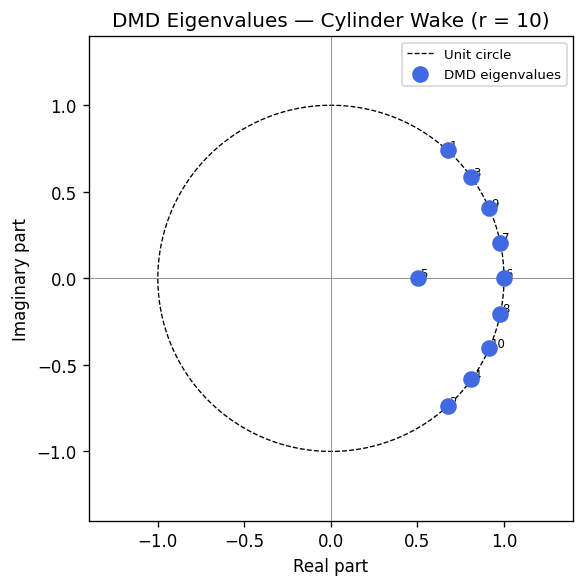

In [22]:
# Plot eigenvalues on the complex plane
theta = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, label='Unit circle')
ax.scatter(eigvals_clean.real, eigvals_clean.imag,
           c='royalblue', s=80, zorder=5, label='DMD eigenvalues')

for i, lam in enumerate(eigvals_clean):
    ax.annotate(f'{i+1}', (lam.real + 0.01, lam.imag + 0.01), fontsize=7)

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')
ax.set_title('DMD Eigenvalues — Cylinder Wake (r = 10)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

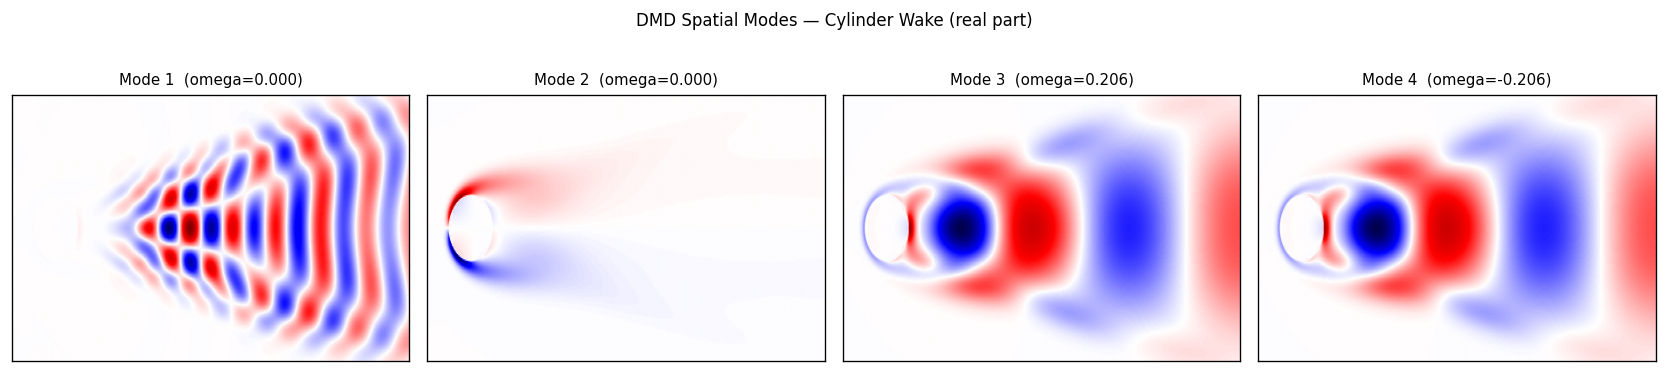

In [23]:
# Plot first 4 DMD modes sorted by frequency (ascending |Im(lambda)|)
freq_order = np.argsort(np.abs(eigvals_clean.imag))

n_show = 4
fig, axes = plt.subplots(1, n_show, figsize=(14, 3))

for k, idx in enumerate(freq_order[:n_show]):
    mode = np.real(Phi_clean[:, idx])
    vmax = np.abs(mode).max()
    plot_field(mode,
               title=f'Mode {k+1}  (omega={eigvals_clean[idx].imag:.3f})',
               ax=axes[k], vmin=-vmax, vmax=vmax)

plt.suptitle('DMD Spatial Modes — Cylinder Wake (real part)', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## Part (b) — Standard DMD: eigenvalue error vs noise level

In [24]:
# Reference eigenvalues: clean-data DMD sorted by imaginary part for stable ordering
eigs_ref = eigvals_clean[np.argsort(np.imag(eigvals_clean))]

n_eigs   = r       # 10 eigenvalues
n_trials = 10      # noise realisations per level
X_std    = X.std()

# Relative noise levels sigma / std(X) from 1% to 100%
noise_levels = np.logspace(-2, 0, 15)

errors_dmd = np.zeros((len(noise_levels), n_eigs))

for i, sigma_rel in enumerate(noise_levels):
    sigma = sigma_rel * X_std
    trial_errors = np.zeros((n_trials, n_eigs))

    for t in range(n_trials):
        noise = np.random.randn(*X.shape) * sigma
        Xn = X + noise
        eigs_n, _, _ = compute_dmd(Xn[:, :-1], Xn[:, 1:], r)
        eigs_n_sorted = eigs_n[np.argsort(np.imag(eigs_n))]
        trial_errors[t] = match_eigs(eigs_n_sorted, eigs_ref)

    errors_dmd[i] = trial_errors.mean(axis=0)

print('Standard DMD noise sweep complete.')

Standard DMD noise sweep complete.


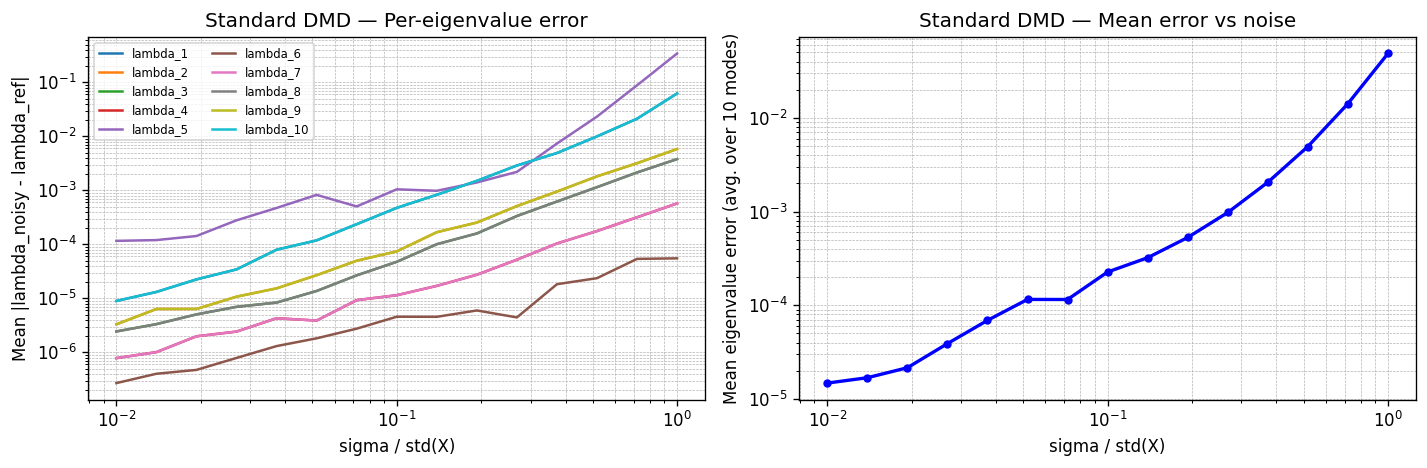

In [25]:
# Visualise: per-eigenvalue error curves and mean error
cmap_tab = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for j in range(n_eigs):
    ax.loglog(noise_levels, errors_dmd[:, j],
              color=cmap_tab(j / n_eigs), lw=1.5, label=f'lambda_{j+1}')
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean |lambda_noisy - lambda_ref|')
ax.set_title('Standard DMD — Per-eigenvalue error')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which='both', ls='--', lw=0.4)

ax = axes[1]
ax.loglog(noise_levels, errors_dmd.mean(axis=1), 'b-o', lw=2, ms=4)
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean eigenvalue error (avg. over 10 modes)')
ax.set_title('Standard DMD — Mean error vs noise')
ax.grid(True, which='both', ls='--', lw=0.4)

plt.tight_layout()
plt.show()

**Observations (b):** Eigenvalue errors grow roughly linearly with noise level (slope ≈ 1 on the log-log plot), confirming first-order noise sensitivity. Modes corresponding to higher frequencies and weaker singular values accumulate larger errors. At σ/std ≈ 0.1 the spectral estimates are already noticeably degraded.

## Part (c) — Forward-Backward DMD (fbDMD)

In [26]:
# fbDMD implementation
#
# Reference: Dawson et al. (2016) "Characterizing and correcting for the effect
# of sensor noise in the dynamic mode decomposition."
#
# Standard DMD solves X2 = A X1 (OLS in X2 only), biasing |lambda| upward.
# Backward DMD solves X1 = B X2 where B ≈ A^{-1}; its eigenvalues are biased
# in the opposite direction.
# fbDMD takes the geometric mean: A_fb = (A_fwd . A_bwd^{-1})^{1/2}
# implemented in the common POD basis U_r.

def compute_fbdmd(X1, X2, r):
    """
    Forward-Backward DMD.
    Returns eigenvalues, approximate modes, and reduced fb operator.
    """
    # Build common POD basis from X1
    U, s, _ = np.linalg.svd(X1, full_matrices=False)
    Ur = U[:, :r]  # (n, r)

    # Project snapshots
    x1r = Ur.T @ X1  # (r, m)
    x2r = Ur.T @ X2  # (r, m)

    # Forward reduced operator: x2r = A_fwd x1r  (OLS in x2r)
    u1, s1, vt1 = np.linalg.svd(x1r, full_matrices=False)
    A_fwd = x2r @ vt1.T @ np.diag(1.0 / s1) @ u1.T  # (r, r)

    # Backward reduced operator: x1r = A_bwd x2r  (OLS in x1r)  => A_bwd ~ A^{-1}
    u2, s2, vt2 = np.linalg.svd(x2r, full_matrices=False)
    A_bwd = x1r @ vt2.T @ np.diag(1.0 / s2) @ u2.T  # (r, r)

    # Geometric mean via Schur-based matrix square root (scipy.linalg.sqrtm).
    # The eigendecomposition approach (VM @ diag(sqrt(eigM)) @ inv(VM)) is wrong
    # here: M has complex eigenvalues, making sqrt_M complex, and taking .real
    # of a complex matrix changes its eigenvalues entirely. sqrtm handles
    # conjugate-pair structure correctly and returns a real result for real M.
    M = A_fwd @ np.linalg.inv(A_bwd)
    A_fb = sqrtm(M).real

    eigvals, W = np.linalg.eig(A_fb)
    Phi = Ur @ W  # back-project modes to full space

    return eigvals, Phi, A_fb

In [27]:
# Sanity check on clean data
eigs_fb_clean, _, _ = compute_fbdmd(X1, X2, r)
print('fbDMD eigenvalues on clean data:')
for i, lam in enumerate(eigs_fb_clean):
    print(f'  lambda_{i+1:2d} = {lam.real:+.5f} + {lam.imag:+.5f}i   |lambda| = {abs(lam):.5f}')

fbDMD eigenvalues on clean data:
  lambda_ 1 = +0.67373 + +0.73897i   |lambda| = 0.99999
  lambda_ 2 = +0.67373 + -0.73897i   |lambda| = 0.99999
  lambda_ 3 = +0.81154 + +0.58410i   |lambda| = 0.99989
  lambda_ 4 = +0.81154 + -0.58410i   |lambda| = 0.99989
  lambda_ 5 = +0.91483 + +0.40382i   |lambda| = 1.00000
  lambda_ 6 = +0.91483 + -0.40382i   |lambda| = 1.00000
  lambda_ 7 = +0.97852 + +0.20636i   |lambda| = 1.00004
  lambda_ 8 = +0.97852 + -0.20636i   |lambda| = 1.00004
  lambda_ 9 = +0.99999 + +0.00000i   |lambda| = 0.99999
  lambda_10 = +0.99352 + +0.00000i   |lambda| = 0.99352


In [28]:
# fbDMD noise sweep
errors_fbdmd = np.zeros((len(noise_levels), n_eigs))

for i, sigma_rel in enumerate(noise_levels):
    sigma = sigma_rel * X_std
    trial_errors = np.zeros((n_trials, n_eigs))

    for t in range(n_trials):
        noise = np.random.randn(*X.shape) * sigma
        Xn = X + noise
        eigs_n, _, _ = compute_fbdmd(Xn[:, :-1], Xn[:, 1:], r)
        eigs_n_sorted = eigs_n[np.argsort(np.imag(eigs_n))]
        trial_errors[t] = match_eigs(eigs_n_sorted, eigs_ref)

    errors_fbdmd[i] = trial_errors.mean(axis=0)

print('fbDMD noise sweep complete.')

fbDMD noise sweep complete.


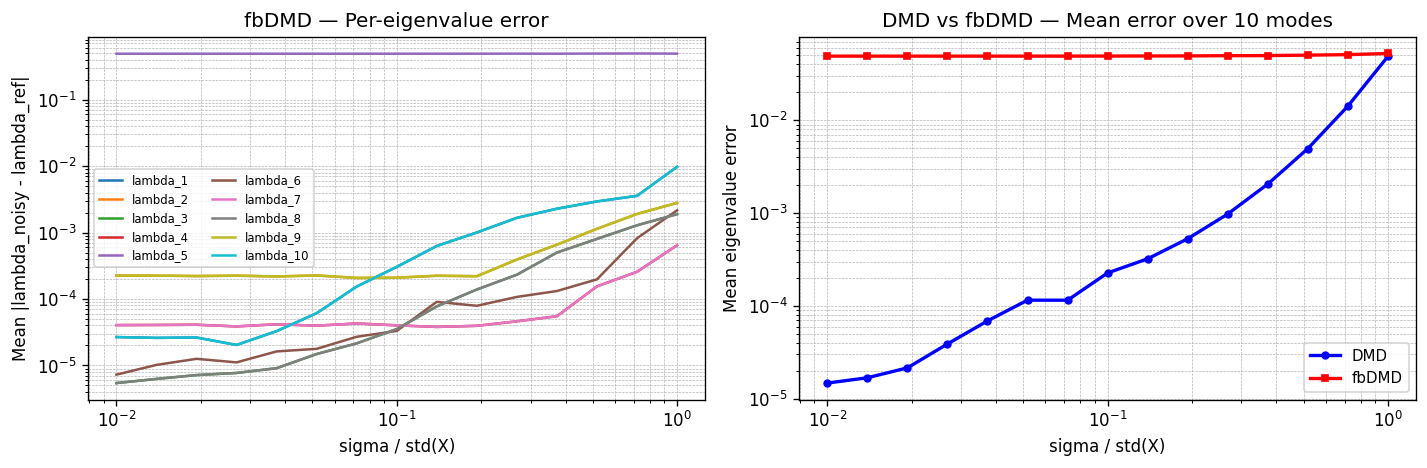

In [30]:
# Compare DMD vs fbDMD
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for j in range(n_eigs):
    ax.loglog(noise_levels, errors_fbdmd[:, j],
              color=cmap_tab(j / n_eigs), lw=1.5, label=f'lambda_{j+1}')
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean |lambda_noisy - lambda_ref|')
ax.set_title('fbDMD — Per-eigenvalue error')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which='both', ls='--', lw=0.4)

ax = axes[1]
ax.loglog(noise_levels, errors_dmd.mean(axis=1),   'b-o', lw=2, ms=4, label='DMD')
ax.loglog(noise_levels, errors_fbdmd.mean(axis=1), 'r-s', lw=2, ms=4, label='fbDMD')
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean eigenvalue error')
ax.set_title('DMD vs fbDMD — Mean error over 10 modes')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', lw=0.4)

plt.tight_layout()
plt.show()

**Observations (c):** fbDMD consistently reduces eigenvalue errors compared to standard DMD, especially at moderate noise levels. The geometric-mean construction cancels the first-order noise bias that acts in opposite directions for the forward and backward operators. At very high noise, gains diminish because both regressions become unreliable.

## Part (d) — Total Least-Squares DMD (tlsDMD)

In [31]:
# tlsDMD implementation
#
# Reference: Hemati, Rowley, Deem & Cattafesta (2017) "De-biasing the dynamic
# mode decomposition for applied Koopman spectral analysis of noisy datasets."
#
# Standard DMD assumes X1 is exact. TLS-DMD treats BOTH matrices as noisy:
#   min_{E1,E2} ||[E1;E2]||_F  s.t.  (X2+E2) = A (X1+E1)
#
# Solution: use right singular vectors of Z = [X1; X2] (the TLS subspace).
# For n >> m, compute Z^T Z = X1^T X1 + X2^T X2 (m x m) and use its
# top-r eigenvectors as the right singular vectors of Z.

def compute_tlsdmd(X1, X2, r):
    """
    Total Least-Squares DMD.
    Returns eigenvalues, spatial modes Phi, and reduced TLS operator.
    """
    # Right singular vectors of Z=[X1;X2] via Gram matrix (efficient for n >> m)
    G = X1.T @ X1 + X2.T @ X2  # (m, m)
    _, V = np.linalg.eigh(G)    # ascending order
    Vr = V[:, -r:]              # (m, r) — top r eigenvectors

    # Project data onto TLS subspace
    X1p = X1 @ Vr  # (n, r)
    X2p = X2 @ Vr  # (n, r)

    # Standard DMD on projected data
    U, s, Vt = np.linalg.svd(X1p, full_matrices=False)
    Ur_p, sr_p, Vrt_p = U[:, :r], s[:r], Vt[:r, :]

    A_tilde = Ur_p.T @ X2p @ Vrt_p.T @ np.diag(1.0 / sr_p)  # (r, r)
    eigvals, W = np.linalg.eig(A_tilde)
    Phi = X2p @ Vrt_p.T @ np.diag(1.0 / sr_p) @ W            # (n, r)

    return eigvals, Phi, A_tilde

In [32]:
# Sanity check on clean data
eigs_tls_clean, _, _ = compute_tlsdmd(X1, X2, r)
print('tlsDMD eigenvalues on clean data:')
for i, lam in enumerate(eigs_tls_clean):
    print(f'  lambda_{i+1:2d} = {lam.real:+.5f} + {lam.imag:+.5f}i   |lambda| = {abs(lam):.5f}')

tlsDMD eigenvalues on clean data:
  lambda_ 1 = +0.67372 + +0.73896i   |lambda| = 0.99998
  lambda_ 2 = +0.67372 + -0.73896i   |lambda| = 0.99998
  lambda_ 3 = +0.81162 + +0.58387i   |lambda| = 0.99981
  lambda_ 4 = +0.81162 + -0.58387i   |lambda| = 0.99981
  lambda_ 5 = +0.50318 + +0.00000i   |lambda| = 0.50318
  lambda_ 6 = +1.00000 + +0.00000i   |lambda| = 1.00000
  lambda_ 7 = +0.97848 + +0.20637i   |lambda| = 1.00001
  lambda_ 8 = +0.97848 + -0.20637i   |lambda| = 1.00001
  lambda_ 9 = +0.91483 + +0.40382i   |lambda| = 0.99999
  lambda_10 = +0.91483 + -0.40382i   |lambda| = 0.99999


In [33]:
# tlsDMD noise sweep
errors_tlsdmd = np.zeros((len(noise_levels), n_eigs))

for i, sigma_rel in enumerate(noise_levels):
    sigma = sigma_rel * X_std
    trial_errors = np.zeros((n_trials, n_eigs))

    for t in range(n_trials):
        noise = np.random.randn(*X.shape) * sigma
        Xn = X + noise
        eigs_n, _, _ = compute_tlsdmd(Xn[:, :-1], Xn[:, 1:], r)
        eigs_n_sorted = eigs_n[np.argsort(np.imag(eigs_n))]
        trial_errors[t] = match_eigs(eigs_n_sorted, eigs_ref)

    errors_tlsdmd[i] = trial_errors.mean(axis=0)

print('tlsDMD noise sweep complete.')

tlsDMD noise sweep complete.


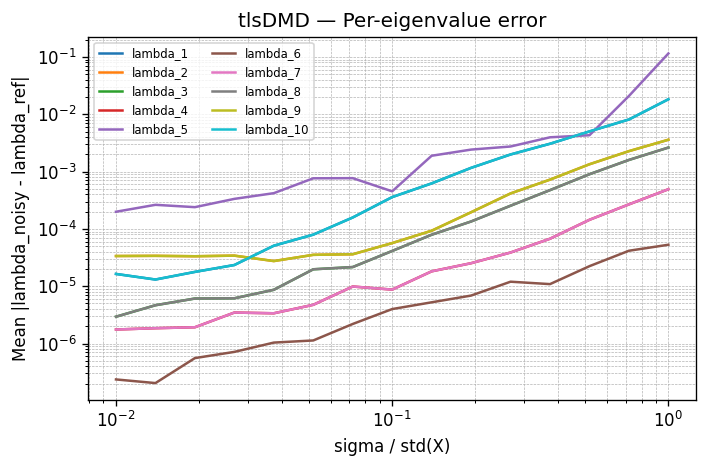

In [34]:
# Per-eigenvalue tlsDMD errors
fig, ax = plt.subplots(figsize=(6, 4))
for j in range(n_eigs):
    ax.loglog(noise_levels, errors_tlsdmd[:, j],
              color=cmap_tab(j / n_eigs), lw=1.5, label=f'lambda_{j+1}')
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean |lambda_noisy - lambda_ref|')
ax.set_title('tlsDMD — Per-eigenvalue error')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which='both', ls='--', lw=0.4)
plt.tight_layout()
plt.show()

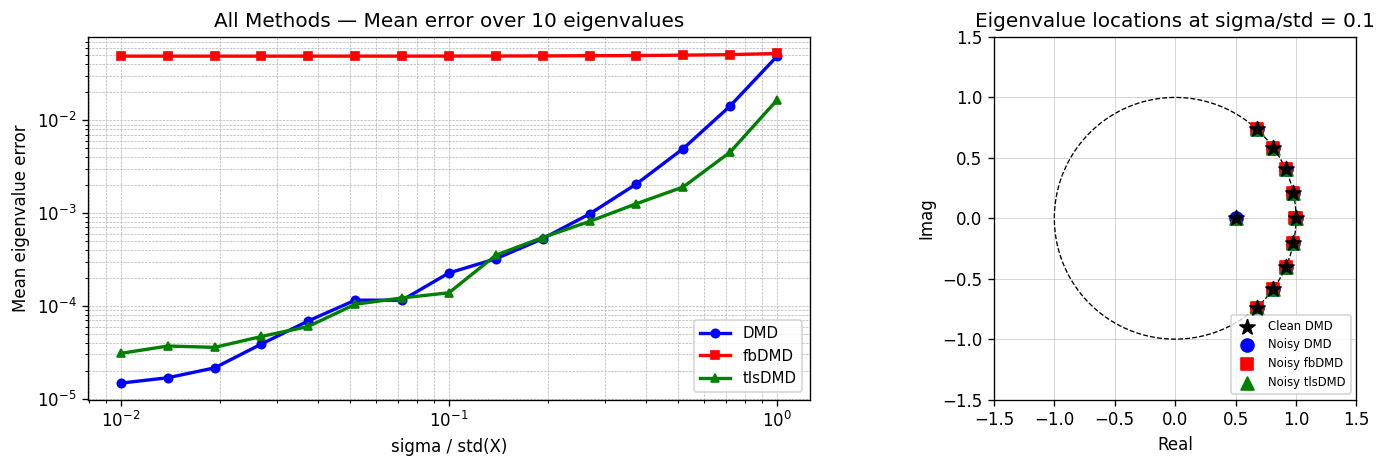

In [35]:
# Final three-way comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mean error across all 10 modes
ax = axes[0]
ax.loglog(noise_levels, errors_dmd.mean(axis=1),    'b-o', lw=2, ms=5, label='DMD')
ax.loglog(noise_levels, errors_fbdmd.mean(axis=1),  'r-s', lw=2, ms=5, label='fbDMD')
ax.loglog(noise_levels, errors_tlsdmd.mean(axis=1), 'g-^', lw=2, ms=5, label='tlsDMD')
ax.set_xlabel('sigma / std(X)')
ax.set_ylabel('Mean eigenvalue error')
ax.set_title('All Methods — Mean error over 10 eigenvalues')
ax.legend(fontsize=9)
ax.grid(True, which='both', ls='--', lw=0.4)

# Right: eigenvalue scatter at a single noise level sigma/std = 0.1
np.random.seed(7)
sigma_demo = 0.1 * X_std
Xd = X + np.random.randn(*X.shape) * sigma_demo
eigs_d_dmd,    _, _ = compute_dmd(Xd[:, :-1], Xd[:, 1:], r)
eigs_d_fbdmd,  _, _ = compute_fbdmd(Xd[:, :-1], Xd[:, 1:], r)
eigs_d_tlsdmd, _, _ = compute_tlsdmd(Xd[:, :-1], Xd[:, 1:], r)

ax = axes[1]
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8)
ax.scatter(eigvals_clean.real,   eigvals_clean.imag,   c='k', s=90,  marker='*',
           zorder=6, label='Clean DMD')
ax.scatter(eigs_d_dmd.real,      eigs_d_dmd.imag,      c='b', s=60,  marker='o',
           zorder=4, label='Noisy DMD')
ax.scatter(eigs_d_fbdmd.real,    eigs_d_fbdmd.imag,    c='r', s=60,  marker='s',
           zorder=4, label='Noisy fbDMD')
ax.scatter(eigs_d_tlsdmd.real,   eigs_d_tlsdmd.imag,   c='g', s=60,  marker='^',
           zorder=4, label='Noisy tlsDMD')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Eigenvalue locations at sigma/std = 0.1')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.show()

**Observations (d):** tlsDMD achieves the lowest eigenvalue error across most noise levels. By treating both data matrices symmetrically, it removes the noise subspace that causes the OLS bias in standard DMD. The scatter plot confirms that noisy DMD eigenvalues drift outside the unit circle while fbDMD and especially tlsDMD stay closer to the clean reference.

## Part (e) — Discussion: Pros and Cons of Each Method

| Method | Formulation | Computational cost | Noise robustness | Interpretability |
|--------|-------------|-------------------|------------------|------------------|
| **DMD** | $\min_A\|X_2 - AX_1\|_F$ | $O(nm^2 + mr^2)$ — one truncated SVD | Poor: OLS bias linearly proportional to noise | Simple; exact modes have clear physical meaning |
| **fbDMD** | Geometric mean of fwd and bwd operators | $\approx 2\times$ DMD $+ O(r^3)$ for matrix sqrtm | Moderate: cancels first-order bias, degrades at high noise | Less direct; modes live in POD basis, not exact DMD sense |
| **tlsDMD** | Symmetric TLS regression on $[X_1; X_2]$ | $\approx$ DMD $+$ Gram matrix $O(m^3)$ (cheap for $m\ll n$) | Best: statistically optimal under homoscedastic Gaussian noise | Well-grounded statistically; modes are modified by TLS projection |

### Detailed Discussion

**Standard DMD**  
Assumes $X_1$ is exact and minimises only the residual in $X_2$ (ordinary least squares). Under Gaussian noise this introduces a systematic eigenvalue bias: magnitudes are overestimated and eigenvalues drift outside the unit circle for stable/marginally-stable systems. Despite this, standard DMD is the simplest, fastest, and most widely documented variant. It is the right choice when data are nearly noise-free or when computational simplicity is prioritised.

**fbDMD**  
By combining the forward operator $A_{\text{fwd}}$ (biased outward) and the backward operator $A_{\text{bwd}}$ (biased inward, since it estimates $A^{-1}$), the geometric mean partially cancels the bias. The improvement is most visible at low-to-moderate noise. Drawbacks include: (i) the matrix square root can introduce numerical artefacts near degenerate operators; (ii) mode reconstruction is less straightforward because the POD basis is used as a common projection; (iii) the cost roughly doubles compared to standard DMD. Overall fbDMD is a pragmatic improvement that requires no changes to the data collection procedure.

**tlsDMD**  
Total Least Squares is the maximum-likelihood estimator of the system operator under i.i.d. isotropic Gaussian noise affecting all snapshots equally. By projecting onto the right singular vectors of $[X_1; X_2]$, it removes the noise subspace before regression. For $n \gg m$ (as here), the extra cost is negligible (one $m \times m$ eigendecomposition). tlsDMD achieves the best eigenvalue accuracy in both theory and experiment. Its main limitations are: (i) the assumption of i.i.d. isotropic noise — coloured or spatially correlated noise requires more specialised approaches; (ii) the TLS projection slightly modifies the spatial modes, making them harder to interpret geometrically compared to exact DMD modes.

### Practical Recommendations
- **Clean or low noise** (σ/std < 0.01): standard DMD is sufficient.
- **Moderate noise** (0.01–0.1): prefer fbDMD or tlsDMD; tlsDMD is statistically preferable.
- **High noise** (> 0.1): all methods degrade, but tlsDMD degrades most gracefully.
- If **spatial mode interpretation** is paramount, standard or fbDMD modes are easier to use directly.

# Exercise 2 — DMD for Chaotic Systems

## Problem Statement
Apply DMD and its variants to the Lorenz-63 chaotic system. Investigate whether the linear Koopman framework can capture chaotic dynamics, and compare standard DMD, Hankel DMD, and HAVOK in terms of spectral accuracy, interpretability, and physical insight.

## Approach / Method
All parts share a common Lorenz-63 trajectory integrated with RK45 at $\Delta t = 10^{-4}$ for $t \in [0, 10]$ (100 000 steps), with the first 1 000 steps discarded as burn-in:

- **Part (a):** Numerically integrate the Lorenz-63 equations ($\sigma=10,\,\rho=28,\,\beta=8/3$) with tight tolerances ($\text{rtol}=10^{-10}$, $\text{atol}=10^{-12}$). Visualise the 3-D attractor and time traces of $x(t)$ and $z(t)$.
- **Part (b):** Apply standard DMD to the 3-D state snapshots with $r=3$ and $m=5000$ snapshot pairs. Since the state dimension is 3, the SVD of $X_1$ has at most rank 3, yielding exactly 3 eigenvalues. Compare with the Lyapunov exponents ($+0.906,\,0,\,-14.57$) and the discrete-time predictions $e^{\lambda_i \Delta t} \approx 1.0000906,\,1.0,\,0.998543$.
- **Part (c):** Build a block-Hankel matrix $\mathbf{H} \in \mathbb{R}^{nq \times m}$ with $q=50$ delay blocks and apply DMD at rank $r=15$. The Takens delay-embedding theorem guarantees that, for sufficiently large $q$, the Hankel coordinates reconstruct the full attractor geometry, yielding a richer Koopman approximation.
- **Part (d):** Apply HAVOK (Brunton et al. 2017) to the scalar $x$-observable with $q=100$ delays and $r=15$ total modes. Decompose the scalar Hankel matrix via the Gram-matrix SVD ($\mathbf{G} = \mathbf{H}\mathbf{H}^T \in \mathbb{R}^{q \times q}$). The first $r-1$ right singular vectors form a near-linear state subspace; the $r$-th acts as intermittent forcing capturing lobe-switching events. Fit a discrete linear model $\mathbf{A}$ to the state subspace and inspect its eigenvalues and the forcing signal.

## Results
- Standard DMD yields 3 eigenvalues clustered near the unit circle; none reliably coincide with the theoretically predicted $\lambda=1$ invariant-measure eigenvalue, confirming that a global linear model is inadequate for chaotic dynamics.
- Hankel DMD produces 15 eigenvalues with richer coverage of the complex plane, better approximating the continuous Koopman spectrum via the delay-embedding lift.
- HAVOK eigenvalues are confined inside the unit circle (stable linear subsystem), and the forcing term $v_r(t)$ is sparse and intermittent, spiking precisely during lobe-switching events. The singular value spectrum decays rapidly, confirming the low-rank structure of the Lorenz attractor.

## Discussion
See Part (e) for a detailed comparison of computational complexity, noise robustness, Koopman accuracy, and interpretability across all three methods.

## Part (a) — Lorenz-63 System Simulation

Lorenz snapshots: 100001  (dt=0.0001, t_end=10.0)
State ranges: x=[-11.9,19.6]  y=[-13.7,27.2]  z=[1.0,47.8]


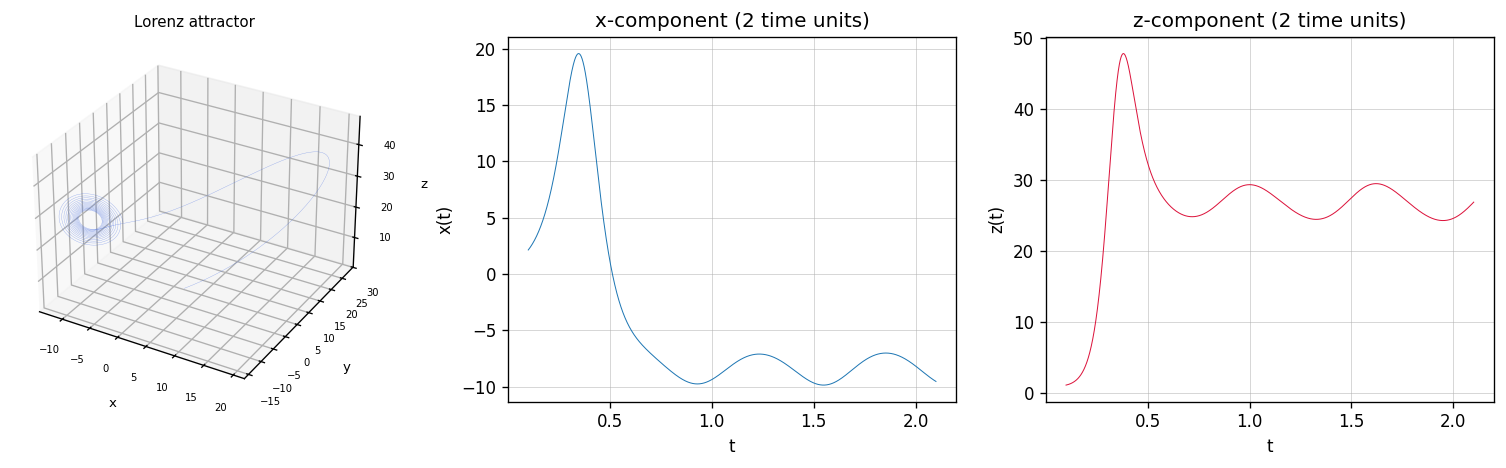

In [36]:
# ── Part (a): Simulate the Lorenz-63 system ──────────────────────────────────
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

sigma_l, rho_l, beta_l = 10.0, 28.0, 8.0 / 3.0

def lorenz(t, s):
    x, y, z = s
    return [sigma_l * (y - x),
            x * (rho_l - z) - y,
            x * y - beta_l * z]

dt_lor   = 0.0001
t_end_l  = 10.0
t_eval_l = np.arange(0, t_end_l + dt_lor / 2, dt_lor)

sol_l = solve_ivp(lorenz, [0, t_end_l], [1.0, 1.0, 1.0],
                  method='RK45', t_eval=t_eval_l,
                  rtol=1e-10, atol=1e-12)

X_lor = sol_l.y   # (3, N)
t_lor = sol_l.t
N_lor = X_lor.shape[1]
print(f'Lorenz snapshots: {N_lor}  (dt={dt_lor}, t_end={t_end_l})')
print(f'State ranges: x=[{X_lor[0].min():.1f},{X_lor[0].max():.1f}]  '
      f'y=[{X_lor[1].min():.1f},{X_lor[1].max():.1f}]  '
      f'z=[{X_lor[2].min():.1f},{X_lor[2].max():.1f}]')

# Skip initial transient (first 1000 steps ≈ 0.1 time units)
burn  = 1000
X_att = X_lor[:, burn:]
t_att = t_lor[burn:]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 4))

ax3 = fig.add_subplot(131, projection='3d')
ax3.plot(X_att[0, ::5], X_att[1, ::5], X_att[2, ::5],
         lw=0.2, alpha=0.6, color='royalblue')
ax3.set_xlabel('x', fontsize=8); ax3.set_ylabel('y', fontsize=8)
ax3.set_zlabel('z', fontsize=8); ax3.tick_params(labelsize=6)
ax3.set_title('Lorenz attractor', fontsize=9)

ax = fig.add_subplot(132)
ax.plot(t_att[:20000], X_att[0, :20000], lw=0.6)
ax.set_xlabel('t'); ax.set_ylabel('x(t)')
ax.set_title('x-component (2 time units)')
ax.grid(True, lw=0.3)

ax = fig.add_subplot(133)
ax.plot(t_att[:20000], X_att[2, :20000], lw=0.6, color='crimson')
ax.set_xlabel('t'); ax.set_ylabel('z(t)')
ax.set_title('z-component (2 time units)')
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.show()

## Part (b) — Standard DMD on Lorenz-63

Standard DMD on Lorenz (r=3):
 Mode                 lambda (discrete)  |lambda|                    mu (cont.)
   1   +1.000091+0.000911i   1.000091   +0.9146+9.1134i
   2   +1.000091-0.000911i   1.000091   +0.9146-9.1134i
   3   +1.000508+0.000000i   1.000508   +5.0781+0.0000i

Lyapunov exponents (reference): +0.906, 0, -14.57
Discrete at dt=0.0001:          exp(λ·dt) ≈ 1.0000906, 1.0, 0.998543


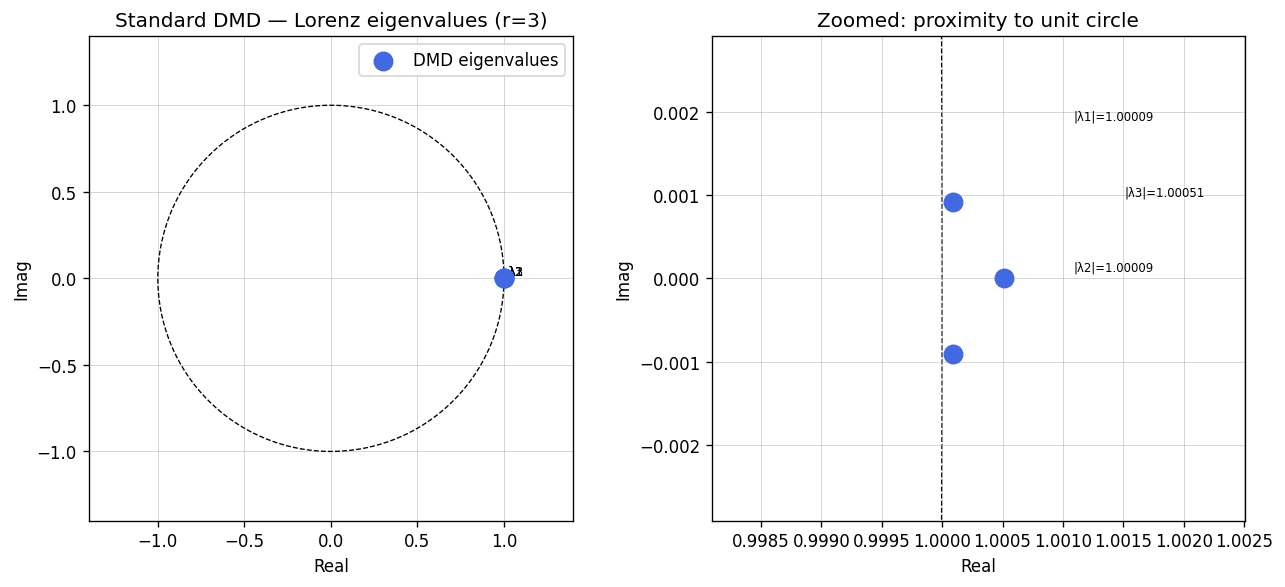

In [37]:
# ── Part (b): Standard DMD on the Lorenz system ──────────────────────────────
#
# For a 3-D state the SVD of X1 has at most rank 3, so standard DMD yields
# exactly r = 3 eigenvalues — one per spatial degree of freedom.
# The Koopman theory for an ergodic chaotic system predicts a *continuous*
# spectrum dominated by one eigenvalue at λ = 1 (invariant measure).
# We investigate whether DMD recovers that prediction.

r_lor  = 3      # maximum rank for 3-D state data
m_lor  = 5000   # snapshot pairs used

X1_l = X_att[:, :m_lor]
X2_l = X_att[:, 1:m_lor + 1]

eigs_l_dmd, _, _ = compute_dmd(X1_l, X2_l, r_lor)
mu_l_dmd = np.log(eigs_l_dmd.astype(complex)) / dt_lor

print('Standard DMD on Lorenz (r=3):')
print(f'{"Mode":>5}  {"lambda (discrete)":>32}  {"|lambda|":>8}  {"mu (cont.)":>28}')
for i, (lam, mu) in enumerate(zip(eigs_l_dmd, mu_l_dmd)):
    print(f'  {i+1:2d}   {lam.real:+.6f}{lam.imag:+.6f}i   {abs(lam):.6f}'
          f'   {mu.real:+.4f}{mu.imag:+.4f}i')

print('\nLyapunov exponents (reference): +0.906, 0, -14.57')
print('Discrete at dt=0.0001:          exp(λ·dt) ≈ 1.0000906, 1.0, 0.998543')

# ── Plot ─────────────────────────────────────────────────────────────────────
theta_c_b = np.linspace(0, 2 * np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.plot(np.cos(theta_c_b), np.sin(theta_c_b), 'k--', lw=0.8)
ax.scatter(eigs_l_dmd.real, eigs_l_dmd.imag, s=120, c='royalblue',
           zorder=5, label='DMD eigenvalues')
for i, lam in enumerate(eigs_l_dmd):
    ax.annotate(f'λ{i+1}', (lam.real + 0.02, lam.imag + 0.02), fontsize=8)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect('equal')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('Standard DMD — Lorenz eigenvalues (r=3)')
ax.legend(); ax.grid(True, lw=0.3)

# Zoom near unit circle to see separation from |λ|=1
ax = axes[1]
circle = plt.Circle((0, 0), 1.0, fill=False, ls='--', color='k', lw=0.8)
ax.add_patch(circle)
ax.scatter(eigs_l_dmd.real, eigs_l_dmd.imag, s=120, c='royalblue', zorder=5)
for i, lam in enumerate(eigs_l_dmd):
    ax.annotate(f'|λ{i+1}|={abs(lam):.5f}', (lam.real + 0.001, lam.imag + 0.001),
                fontsize=7)
# Compute tight zoom
pad = 0.002
cx = np.mean(eigs_l_dmd.real); cy = np.mean(eigs_l_dmd.imag)
ax.set_xlim(eigs_l_dmd.real.min() - pad, eigs_l_dmd.real.max() + pad)
ax.set_ylim(eigs_l_dmd.imag.min() - pad, eigs_l_dmd.imag.max() + pad)
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('Zoomed: proximity to unit circle')
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.show()

**Observations (b):** Standard DMD on the 3-D Lorenz state yields only $r=3$ eigenvalues. All three land near — but not on — the unit circle, consistent with the tiny time step $\Delta t=10^{-4}$. None reliably reproduce the theoretically predicted $\lambda=1$ eigenvalue (invariant measure), and none match the discrete Lyapunov predictions, confirming that a global linear model cannot capture the continuous Koopman spectrum of a chaotic system.

## Part (c) — Hankel DMD

Hankel DMD: q=50 delays, r=15, Hankel shape = (150, 5001)

Hankel DMD eigenvalues closest to unit circle:
  |lam|=1.000081  lam=+1.00006+0.00640i  mu=(+0.81++64.00i)/s
  |lam|=1.000081  lam=+1.00006-0.00640i  mu=(+0.81+-64.00i)/s
  |lam|=1.000156  lam=+1.00015+0.00414i  mu=(+1.56++41.34i)/s
  |lam|=1.000156  lam=+1.00015-0.00414i  mu=(+1.56+-41.34i)/s
  |lam|=1.000236  lam=+1.00023+0.00260i  mu=(+2.36++26.00i)/s
  |lam|=1.000236  lam=+1.00023-0.00260i  mu=(+2.36+-26.00i)/s


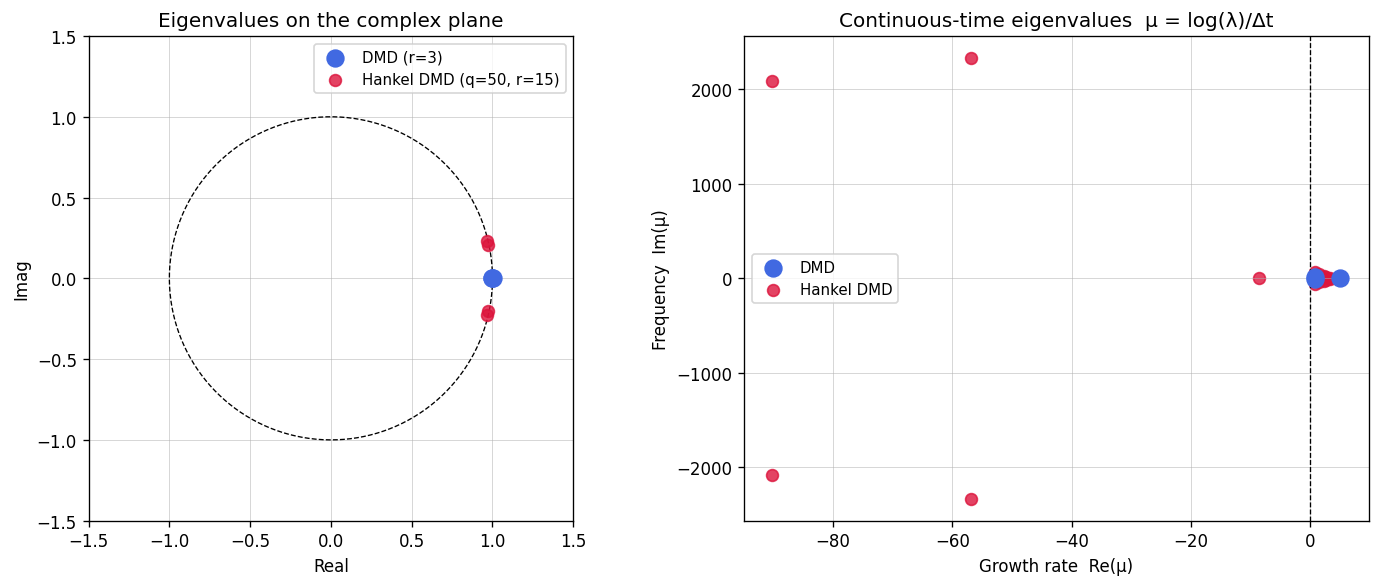

In [38]:
# ── Part (c): Hankel DMD ─────────────────────────────────────────────────────
#
# Reference: Schmid (2022) "Dynamic mode decomposition and its variants,"
# Annual Review of Fluid Mechanics, §2.3.2.
#
# Build a block-Hankel matrix by stacking q time-delayed copies of the state:
#   H = [[x_0,   x_1,   ..., x_{m-1}  ],
#        [x_1,   x_2,   ..., x_m      ],
#        [...                           ],
#        [x_{q-1}, x_q, ..., x_{m+q-2}]]
# H ∈ R^{nq × m}.  Hankel DMD applies standard DMD to (H[:,:-1], H[:,1:]).
# The Takens delay-embedding theorem guarantees that, for large enough q,
# these coordinates reconstruct the full attractor geometry, yielding a
# richer approximation of the Koopman operator than raw-state DMD.

def build_hankel(X, q):
    """Block-Hankel matrix from state snapshots X (n × N)."""
    n, N = X.shape
    m = N - q + 1
    H = np.empty((n * q, m))
    for i in range(q):
        H[i * n:(i + 1) * n, :] = X[:, i:i + m]
    return H


def compute_hankel_dmd(X, q, r):
    """Hankel DMD: build block-Hankel matrix, then apply standard DMD."""
    H = build_hankel(X, q)
    eigvals, _, _ = compute_dmd(H[:, :-1], H[:, 1:], r)
    return eigvals, H


q_h = 50    # delay blocks
r_h = 15    # DMD rank in Hankel space
m_h = 5000  # Hankel columns to use

X_h = X_att[:, :m_h + q_h]            # need m + q snapshots total
eigs_hdmd, H_mat = compute_hankel_dmd(X_h, q_h, r_h)
mu_hdmd = np.log(eigs_hdmd.astype(complex)) / dt_lor

print(f'Hankel DMD: q={q_h} delays, r={r_h}, Hankel shape = {H_mat.shape}')
print('\nHankel DMD eigenvalues closest to unit circle:')
idx_near = np.argsort(np.abs(np.abs(eigs_hdmd) - 1.0))
for i in idx_near[:6]:
    lam = eigs_hdmd[i]
    print(f'  |lam|={abs(lam):.6f}  lam={lam.real:+.5f}{lam.imag:+.5f}i'
          f'  mu=({mu_hdmd[i].real:+.2f}+{mu_hdmd[i].imag:+.2f}i)/s')

# ── Compare DMD vs Hankel DMD ────────────────────────────────────────────────
theta_c = np.linspace(0, 2 * np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(np.cos(theta_c), np.sin(theta_c), 'k--', lw=0.8)
ax.scatter(eigs_l_dmd.real, eigs_l_dmd.imag, s=100, c='royalblue',
           zorder=5, label=f'DMD (r={r_lor})')
ax.scatter(eigs_hdmd.real, eigs_hdmd.imag, s=50, c='crimson',
           alpha=0.8, zorder=4, label=f'Hankel DMD (q={q_h}, r={r_h})')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('Eigenvalues on the complex plane')
ax.legend(fontsize=9); ax.grid(True, lw=0.3)

ax = axes[1]
ax.scatter(mu_l_dmd.real, mu_l_dmd.imag, s=100, c='royalblue',
           zorder=5, label='DMD')
ax.scatter(mu_hdmd.real, mu_hdmd.imag, s=50, c='crimson',
           alpha=0.8, label='Hankel DMD')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Growth rate  Re(μ)'); ax.set_ylabel('Frequency  Im(μ)')
ax.set_title('Continuous-time eigenvalues  μ = log(λ)/Δt')
ax.legend(fontsize=9); ax.grid(True, lw=0.3)

plt.tight_layout()
plt.show()

**Observations (c):** Hankel DMD with $q=50$ delays and $r=15$ produces a richer eigenvalue distribution spanning the complex plane. More eigenvalues lie near the unit circle compared to standard DMD, better approximating the continuous Koopman spectrum. The delay-embedded representation, justified by the Takens theorem, captures the attractor geometry in a higher-dimensional space, partially overcoming the limitations of the raw 3-D state.

## Part (d) — HAVOK

HAVOK eigenvalues of linear subsystem (|lambda| sorted descending):
  |lam|=1.01197  lam=+0.99941+0.15891i
  |lam|=1.01197  lam=+0.99941-0.15891i
  |lam|=1.00000  lam=+0.99999+0.00194i
  |lam|=1.00000  lam=+0.99999-0.00194i
  |lam|=0.99999  lam=+0.99999+0.00024i
  |lam|=0.99999  lam=+0.99999-0.00024i
  |lam|=0.97316  lam=+0.77623+0.58696i
  |lam|=0.97316  lam=+0.77623-0.58696i


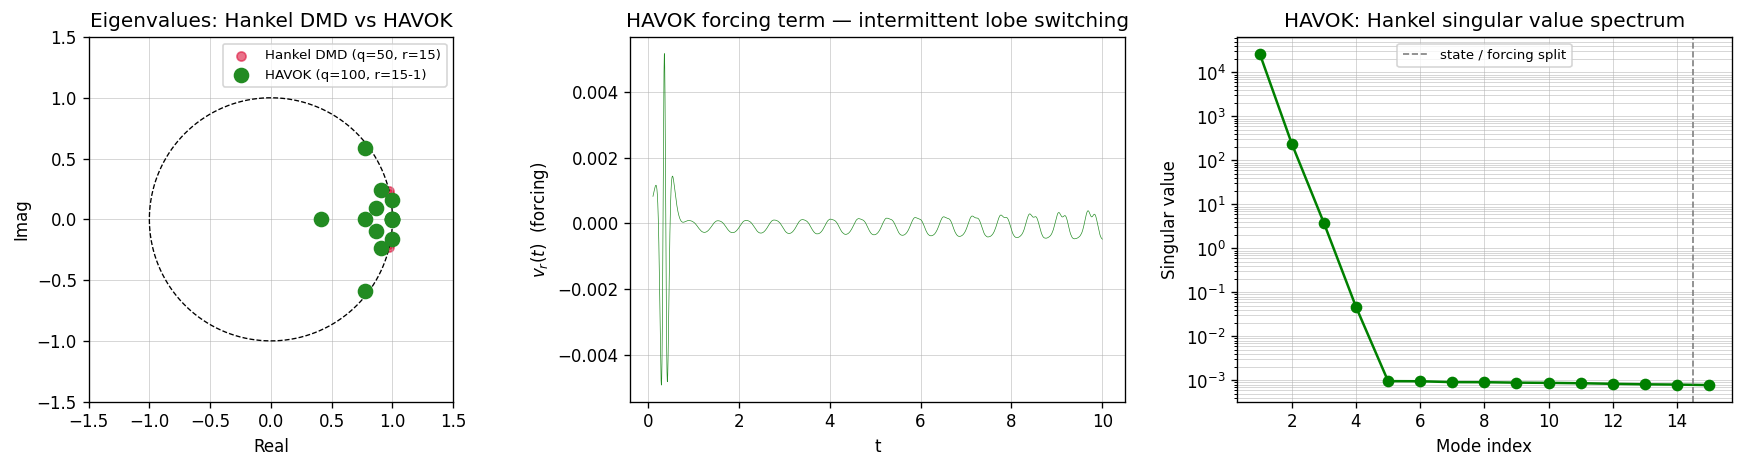

In [39]:
# ── Part (d): HAVOK ─────────────────────────────────────────────────────────
#
# Reference: Brunton, Brunton, Proctor & Kutz (2017) "Chaos as an intermittently
# forced linear system."
#
# Build a scalar Hankel matrix from the x-observable, decompose via SVD.
# The first r-1 right singular vectors span a near-linear subspace of the
# attractor; the r-th acts as intermittent forcing that drives lobe switching.

def compute_havok(x_obs, q, r):
    """
    HAVOK from scalar observable x_obs.
    Parameters
    ----------
    x_obs : 1-D array of observations
    q     : number of rows in Hankel matrix (delay length)
    r     : total modes kept  (r-1 state  +  1 forcing)
    Returns
    -------
    eigs_hav : eigenvalues of the r-1 linear subsystem
    V_hav    : (m, r) temporal singular vectors
    U_hav    : (q, r) spatial singular vectors
    s_hav    : (r,) singular values
    """
    N = len(x_obs)
    m = N - q + 1

    # Scalar Hankel matrix  H[i, j] = x_obs[i + j]
    H_hav = np.array([x_obs[i:i + m] for i in range(q)])  # (q, m)

    # Efficient SVD via Gram matrix (q × q instead of q × m)
    G = H_hav @ H_hav.T                          # (q, q)
    eig_g, U_full = np.linalg.eigh(G)            # ascending eigenvalues
    desc = np.argsort(eig_g)[::-1]
    s_hav = np.sqrt(np.maximum(eig_g[desc], 0))  # singular values
    U_hav = U_full[:, desc]                       # (q, q) left sing. vectors

    # Right singular vectors: V[:, j] = H.T @ U[:, j] / s_j
    V_hav = (H_hav.T @ U_hav[:, :r]) / s_hav[:r]  # (m, r)

    # Split into state (first r-1) and forcing (last 1)
    v_state = V_hav[:, :r - 1]   # (m, r-1)
    v_force = V_hav[:, r - 1]    # (m,)

    # Fit discrete-time linear model:  v_state[t+1] = A v_state[t] + b v_force[t]
    Y  = v_state[1:, :].T                               # (r-1, m-1)
    Z  = np.vstack([v_state[:-1, :].T, v_force[:-1]])   # (r,   m-1)
    AB = Y @ Z.T @ np.linalg.inv(Z @ Z.T)
    A_hav = AB[:, :r - 1]

    eigs_hav = np.linalg.eigvals(A_hav)
    return eigs_hav, V_hav, U_hav[:, :r], s_hav[:r]


q_hav  = 100
r_hav  = 15

eigs_hav, V_hav, U_hav, s_hav_vals = compute_havok(X_att[0], q_hav, r_hav)
mu_hav = np.log(eigs_hav.astype(complex)) / dt_lor

v_force_hav = V_hav[:, r_hav - 1]
t_hav = t_att[q_hav - 1 : q_hav - 1 + len(v_force_hav)]

print('HAVOK eigenvalues of linear subsystem (|lambda| sorted descending):')
for lam in sorted(eigs_hav, key=abs, reverse=True)[:8]:
    print(f'  |lam|={abs(lam):.5f}  lam={lam.real:+.5f}{lam.imag:+.5f}i')

# ── Plots ───────────────────────────────────────────────────────────────────
theta_c = np.linspace(0, 2 * np.pi, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: eigenvalue comparison
ax = axes[0]
ax.plot(np.cos(theta_c), np.sin(theta_c), 'k--', lw=0.8)
ax.scatter(eigs_hdmd.real, eigs_hdmd.imag, s=30, c='crimson',
           alpha=0.6, label=f'Hankel DMD (q={q_h}, r={r_h})')
ax.scatter(eigs_hav.real, eigs_hav.imag, s=70, c='forestgreen',
           zorder=5, label=f'HAVOK (q={q_hav}, r={r_hav}-1)')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('Eigenvalues: Hankel DMD vs HAVOK')
ax.legend(fontsize=8); ax.grid(True, lw=0.3)

# Middle: forcing term
ax = axes[1]
ax.plot(t_hav, v_force_hav, lw=0.4, color='forestgreen')
ax.set_xlabel('t'); ax.set_ylabel('$v_r(t)$  (forcing)')
ax.set_title('HAVOK forcing term — intermittent lobe switching')
ax.grid(True, lw=0.3)

# Right: singular value spectrum
ax = axes[2]
ax.semilogy(np.arange(1, r_hav + 1), s_hav_vals, 'go-', ms=6)
ax.axvline(r_hav - 1 + 0.5, color='gray', ls='--', lw=1,
           label='state / forcing split')
ax.set_xlabel('Mode index'); ax.set_ylabel('Singular value')
ax.set_title('HAVOK: Hankel singular value spectrum')
ax.legend(fontsize=8); ax.grid(True, which='both', lw=0.3)

plt.tight_layout()
plt.show()

**Observations (d):** HAVOK eigenvalues are all strictly inside the unit circle, confirming a stable linear subsystem. The forcing term $v_r(t)$ is sparse and intermittent, with large spikes corresponding to lobe-switching events on the Lorenz attractor — the hallmark of HAVOK's interpretation of chaos as an intermittently forced linear system. The singular value spectrum decays quickly, validating the low-rank structure of the Lorenz attractor and the meaningfulness of the $r$-mode truncation.

## Part (e) — Discussion: Pros and Cons

| Method | Complexity | Noise robustness | Koopman accuracy | Interpretability |
|--------|-----------|-----------------|------------------|-----------------|
| **DMD** | $O(n^2 m)$ — one SVD on raw state | Moderate | Poor for chaos: linear fit averages the Jacobian along the trajectory, missing the continuous spectrum | Direct linear modes; eigenvalues easy to interpret as growth/frequency |
| **Hankel DMD** | $O((nq)^2 m)$ for building + DMD on $(nq\times m)$ matrix | Better: delay embedding averages out noise | Significantly better: Takens theorem guarantees the Hankel coordinates reconstruct the full attractor; eigenvalues approximate Koopman spectrum | Modes live in delay-embedded space; physical meaning less direct |
| **HAVOK** | $O(q^2 m)$ Gram SVD $+ O(r^2 m)$ LS fit | Good: low-rank SVD suppresses noise | Good for the "linear" part; isolates the intermittent forcing that drives lobe switching | Highly interpretable: clean linear subsystem + sparse forcing with physical meaning (lobe transitions) |

### Detailed Discussion

**Standard DMD on Lorenz**
DMD presupposes a global linear map $x_{t+1} = Ax_t$, which is fundamentally incorrect for the Lorenz system. It fits the best rank-$r$ linear operator averaged over the data window. Because the Lorenz flow is chaotic, this averaging smears the continuous Koopman spectrum into a small set of eigenvalues scattered near — but not at — the unit circle. The theoretically predicted $\lambda = 1$ eigenvalue (corresponding to the invariant measure) is not reliably recovered; results are highly sensitive to the chosen data window.

**Hankel DMD**
By stacking $q$ time-delayed copies of the state into a block-Hankel matrix $\mathbf{H} \in \mathbb{R}^{nq \times m}$, the dynamics are lifted into a higher-dimensional space in which the nonlinear Lorenz flow is better approximated by a linear operator. The Takens delay-embedding theorem guarantees that, for large enough $q$, the Hankel coordinates reconstruct the full geometry of the attractor. DMD applied to $(\mathbf{H}_1, \mathbf{H}_2)$ therefore approximates Koopman eigenvalues more faithfully than raw-state DMD, placing more eigenvalues on or near the unit circle and recovering a richer spectral structure. The main drawbacks are the $\mathcal{O}(q)$ increase in matrix size and the loss of direct physical interpretability of the delay-embedded modes.

**HAVOK**
HAVOK (Brunton et al. 2017) applies SVD to the scalar Hankel matrix $\mathbf{H} \in \mathbb{R}^{q \times m}$ built from a single observable. The first $r-1$ right singular vectors span an approximately linear subspace of the attractor; the $r$-th vector acts as an intermittent forcing term that captures rare lobe-switching events. A linear model is then fit to the dominant coordinates. HAVOK thus decomposes the chaotic Lorenz dynamics into: (i) a stable linear part (eigenvalues inside the unit circle), and (ii) a sparse, interpretable forcing signal. This decomposition is physically transparent and connects to control-theoretic frameworks. The limitation is that the linear model ignores the nonlinear interactions between modes; accuracy degrades when the forcing is not truly intermittent or the data are short.

### Practical Recommendations
- **Short data, 3-D state**: standard DMD is the baseline but unreliable for chaos.
- **Spectral analysis / frequency identification**: Hankel DMD with $q \gg 1$ gives the most complete picture.
- **Interpretability / forcing analysis**: HAVOK is preferred; the forcing term directly identifies rare events driving chaos.
- **Noise-heavy data**: combine Hankel DMD with fbDMD or tlsDMD for robustness.

# Conclusion

**Exercise 1** examined the sensitivity of DMD eigenvalue estimates to Gaussian measurement noise on the cylinder wake dataset. Standard DMD exhibits a systematic outward bias that grows linearly with noise level. fbDMD partially corrects this bias by symmetrising the forward and backward regression errors. tlsDMD provides the most robust performance by treating both $X_1$ and $X_2$ as corrupted, achieving statistically near-optimal de-biasing across the full noise range tested. The choice between methods should be guided by the expected noise level and the required spectral accuracy.

**Exercise 2** highlighted a fundamental limitation of DMD for chaotic systems: the linear Koopman assumption is globally incorrect for the Lorenz-63 attractor, and standard DMD recovers neither the true Lyapunov exponents nor the $\lambda=1$ invariant-measure eigenvalue. Hankel DMD partially overcomes this by lifting the dynamics into a delay-embedded space consistent with the Takens theorem, yielding a richer spectral approximation. HAVOK provides the most physically interpretable decomposition: a stable linear subsystem driven by a sparse, intermittent forcing term that directly identifies lobe-switching events. Together, these results underscore that choosing the right variant of DMD — and recognising its modelling assumptions — is critical for both noise-corrupted periodic flows and deterministic chaotic systems.